<center><h1>Xie_Anna_HW2</h1></center>
<br>
<br>

Name: Anna Xie
<br>
Github Username: annajxie
<br>
USC ID: 2277255370

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [14]:
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import statsmodels.api as sm 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import math

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel('Folds5x2_pp.xlsx')

### (b) Exploring the data

#### i. rows and columns

In [3]:
# print(df.shape)
print('There are ' + str(df.shape[0]) + ' rows and ' + str(df.shape[1]) + ' columns.')

There are 9568 rows and 5 columns.


#### ii. pairwise scatterplots of all the varianbles

As the exhaust vacuum increases and ambient temperature increases, the hourly electrical output decreases. 
Conversely, as ambient pressure and relative humidity increase, there is a slight decline in electrical output. 



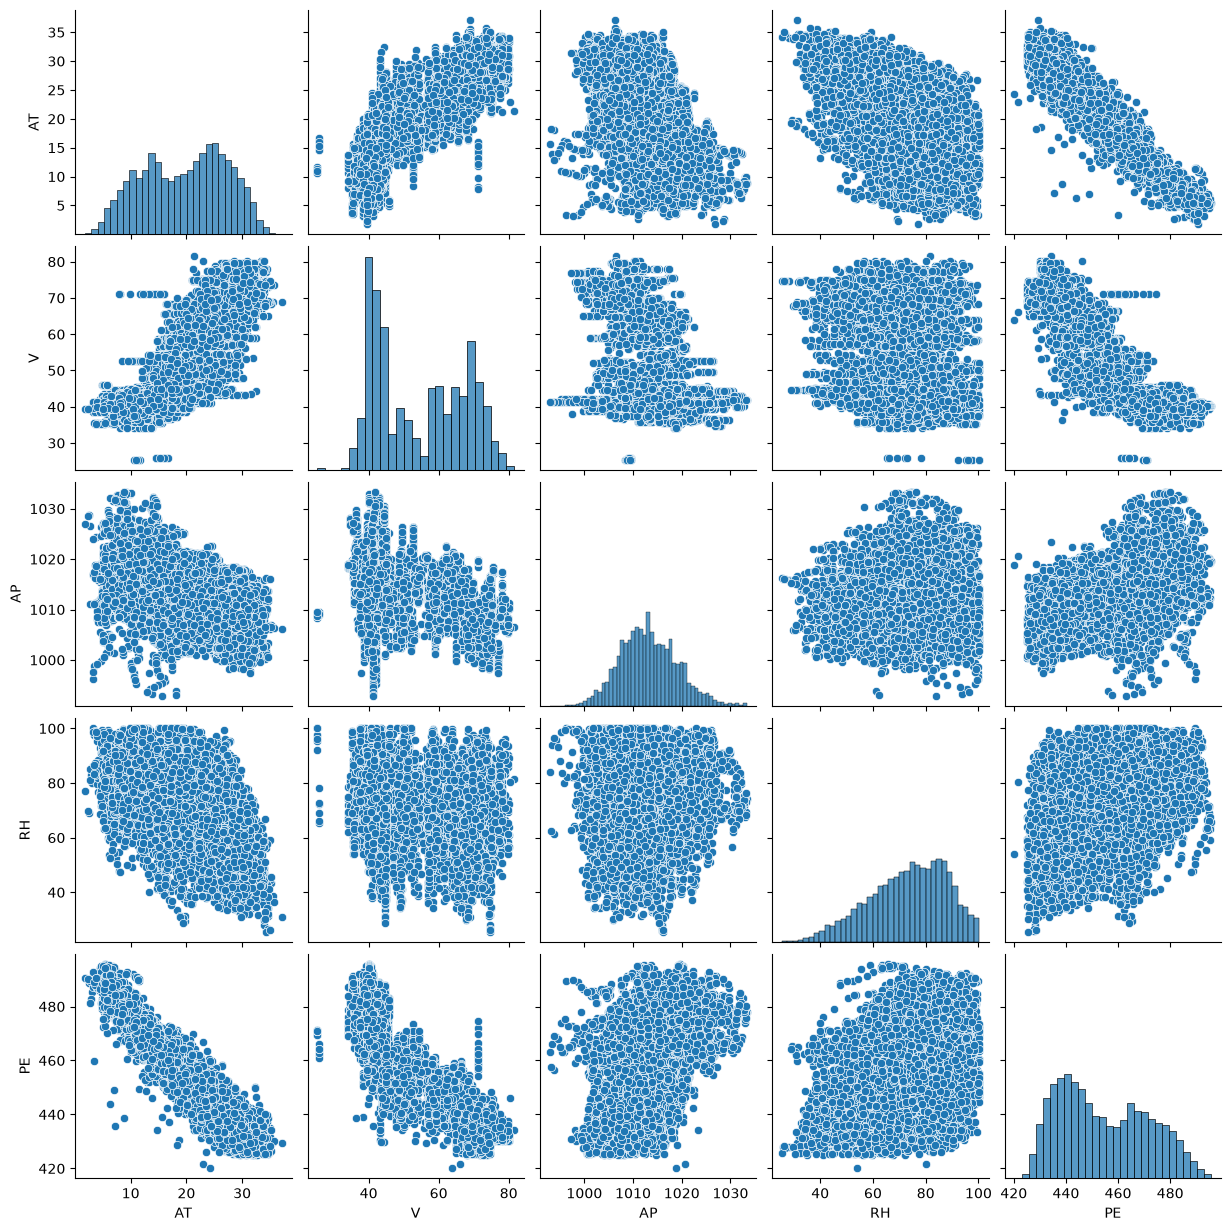

In [4]:
sns.pairplot(df)
# variables: 
# AT, V, AP, RH, PE
# V => exhaust vacuum (25-81 cm Hg)
# AT => temperature (between 1.8 - 37.1 C)
# AP => ambient pressure (between 990-1000 milibar)
# RH => relative humidity (between 25-100%)
# EP => net hourly electrical energy output (in megawatts 420.26-495.76)

print(
  "As the exhaust vacuum increases and ambient temperature increases, the hourly electrical output decreases. \n"+
  'Conversely, as ambient pressure and relative humidity increase, there is a slight decline in electrical output. \n'
  )

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
print(df.describe())
# print('Mean: ' + df.describe)

                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000


### (c) Simple Linear Regression

C:\Users\annax\AppData\Local\Temp\ipykernel_2704\121775753.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()   # fig.show() can silently fail to render in some notebook setups; plt.show() is safer


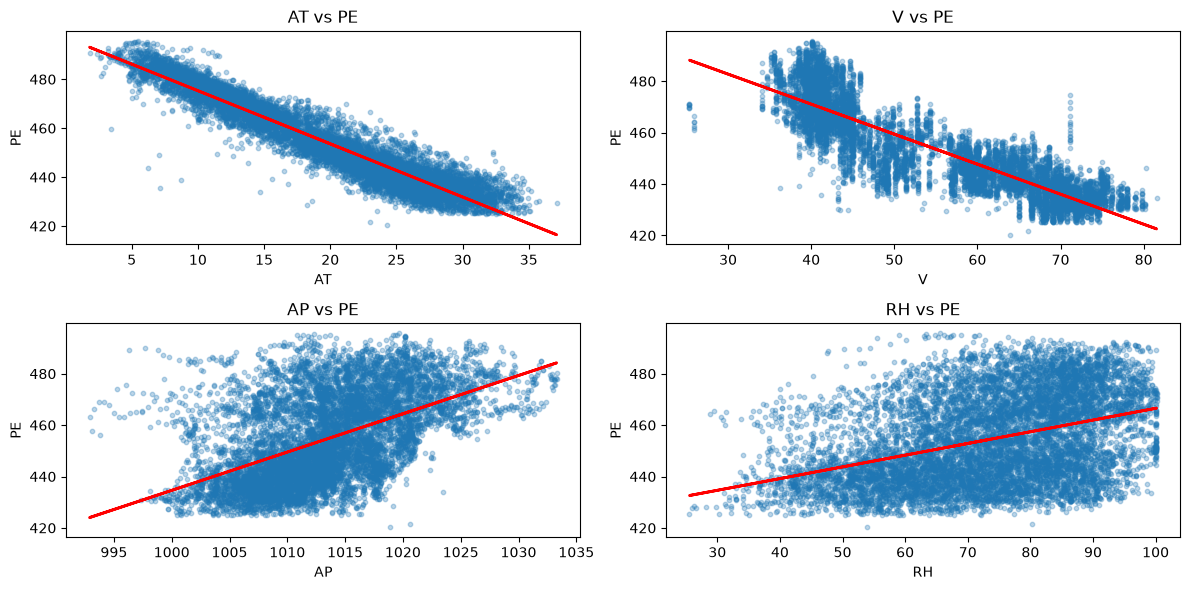

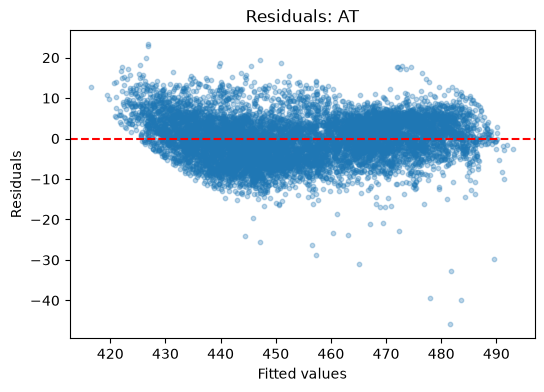

AT: 42 potential outliers (|residual| > 3σ)


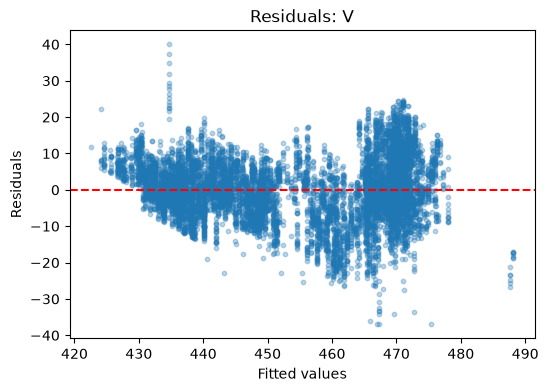

V: 33 potential outliers (|residual| > 3σ)


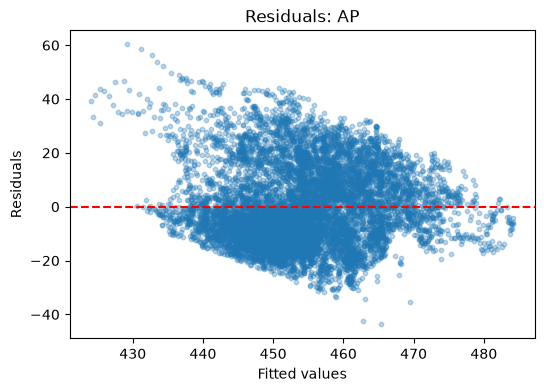

AP: 28 potential outliers (|residual| > 3σ)


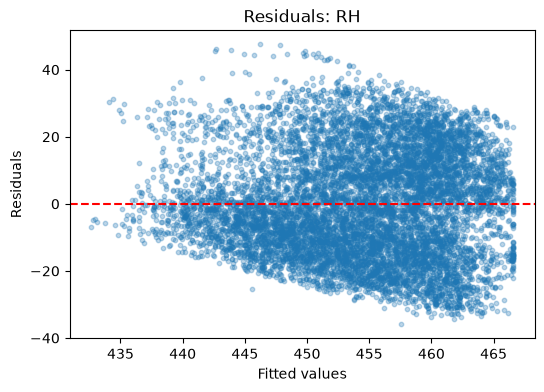

RH: 2 potential outliers (|residual| > 3σ)


In [9]:
predictors = ['AT', 'V', 'AP', 'RH']
target = 'PE'

models = {}
mod_stats = {}

for pred in predictors:
    X = df[[pred]].values      # 2D, shape (n, 1) — sklearn wants this
    y = df[target].values      # 1D, shape (n,) — single brackets

    model = LinearRegression()
    model.fit(X, y)

    predictions = model.predict(X)
    n, k = X.shape

    # degrees of freedom and residual sum of squares
    dof = n - k - 1
    residuals = y - predictions
    mse = np.sum(residuals ** 2) / dof

    x_mean = X.mean()
    se_slope = np.sqrt(mse / np.sum((X.flatten() - x_mean) ** 2))
    t_stat = model.coef_[0] / se_slope
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), dof))

    models[pred] = model
    # Store residuals/fitted here manually, since sklearn models don't carry them
    # the way statsmodels ones do — the residual-plot loop below needs these.
    mod_stats[pred] = {
        'coef': model.coef_[0],
        'p_value': p_value,
        'r2': model.score(X, y),
        'residuals': residuals,
        'fitted': predictions,
    }

# ===== plot regression =====
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for i, pred in enumerate(predictors):
    axes[i].scatter(df[pred], df[target], alpha=0.3, s=10)

    # Fitted line across predictor range — use the SAME single-column shape
    # the model was trained on, not sm.add_constant (that's statsmodels-only)
    x_range = np.sort(df[[pred]].values).reshape(-1, 1)
    y_fit = models[pred].predict(x_range)
    axes[i].plot(x_range, y_fit, color='red', linewidth=2)

    axes[i].set_xlabel(pred)
    axes[i].set_ylabel(target)
    axes[i].set_title(f'{pred} vs {target}')

fig.tight_layout()
fig.show()   # fig.show() can silently fail to render in some notebook setups; plt.show() is safer

# ===== plot residuals =====
for pred in predictors:
    residuals = mod_stats[pred]['residuals']   # pulled from what we stored above
    fitted = mod_stats[pred]['fitted']

    plt.figure(figsize=(6, 4))
    plt.scatter(fitted, residuals, alpha=0.3, s=10)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    plt.title(f'Residuals: {pred}')
    plt.show()

    threshold = 3 * residuals.std()
    outliers = df[np.abs(residuals) > threshold]
    print(f'{pred}: {len(outliers)} potential outliers (|residual| > 3σ)')

### (d) Multiple Regression

In [ ]:
# mutliple regression w all four predictors together 

X_multi_reg = sm.add_constant(df[predictors])
y = df[target]

multi_model_reg = sm.OLS(y, X_multi_reg).fit()

for pred in predictors:
  coef = multi_model_reg.params[pred]
  pval = multi_model_reg.pvalues[pred]
  reject_h0 = 'Yes' if pval < 0.05 else 'no'
  print(f'{pred}: coef={coef:.4f}, p-calue={pval:.2e}, reject H0={reject_h0}')

print(f'\nOverall R-squared: {multi_model_reg.rsquared:.4f}')

### (e) 1c Compare to 1d

In [ ]:
simple_coefs = [mod_stats[pred]['coef'] for pred in predictors]
multi_coefs = [multi_model.params[pred] for pred in predictors]

plt.figure(figsize=(6, 6))
plt.scatter(simple_coefs, multi_coefs)
for i, pred in enumerate(predictors):
    plt.annotate(pred, (simple_coefs[i], multi_coefs[i]))
plt.xlabel('Simple regression coefficient')
plt.ylabel('Multiple regression coefficient')
plt.title('Simple vs Multiple Regression Coefficients')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

### (f) Nonlinear Association

In [ ]:
cubic_models = {}

for pred in predictors:
    X_cubic = pd.DataFrame({
        pred: df[pred],
        f'{pred}^2': df[pred] ** 2,
        f'{pred}^3': df[pred] ** 3,
    })
    X_cubic = sm.add_constant(X_cubic)
    model = sm.OLS(df[target], X_cubic).fit()
    cubic_models[pred] = model
    print(f'--- {pred} (cubic) ---')
    print(model.summary())
    print()

### (g) Interactions of Predictors

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interact = poly.fit_transform(df[predictors])
X_interact_df = pd.DataFrame(X_interact, columns=poly.get_feature_names_out(predictors))

X_interact_const = sm.add_constant(X_interact_df)
interact_model = sm.OLS(df[target], X_interact_const).fit()
print(interact_model.summary())

# Flag significant interaction terms
interaction_cols = [c for c in X_interact_df.columns if ' ' in c]
for col in interaction_cols:
    pval = interact_model.pvalues[col]
    if pval < 0.05:
        print(f'{col}: p={pval:.2e} — significant')

### (h) Improvement

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

# Model 1: all predictors, no interactions
X_train1 = sm.add_constant(train_df[predictors])
X_test1 = sm.add_constant(test_df[predictors])
model1 = sm.OLS(train_df[target], X_train1).fit()

train_mse1 = mean_squared_error(train_df[target], model1.predict(X_train1))
test_mse1 = mean_squared_error(test_df[target], model1.predict(X_test1))
print(f'Model 1 (all predictors): train MSE={train_mse1:.4f}, test MSE={test_mse1:.4f}')

# Model 2: interactions + quadratics, on training data only
poly2 = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train2_arr = poly2.fit_transform(train_df[predictors])
X_test2_arr = poly2.transform(test_df[predictors])
feat_names = poly2.get_feature_names_out(predictors)

X_train2 = pd.DataFrame(X_train2_arr, columns=feat_names, index=train_df.index)
X_test2 = pd.DataFrame(X_test2_arr, columns=feat_names, index=test_df.index)

X_train2_const = sm.add_constant(X_train2)
full_model2 = sm.OLS(train_df[target], X_train2_const).fit()

# Drop insignificant variables (p >= 0.05), keep const
sig_cols = [c for c in X_train2.columns if full_model2.pvalues[c] < 0.05]
print(f'Kept {len(sig_cols)} of {len(feat_names)} terms')

X_train2_reduced = sm.add_constant(X_train2[sig_cols])
X_test2_reduced = sm.add_constant(X_test2[sig_cols])
model2 = sm.OLS(train_df[target], X_train2_reduced).fit()

train_mse2 = mean_squared_error(train_df[target], model2.predict(X_train2_reduced))
test_mse2 = mean_squared_error(test_df[target], model2.predict(X_test2_reduced))
print(f'Model 2 (interactions+quadratics, pruned): train MSE={train_mse2:.4f}, test MSE={test_mse2:.4f}')

### (i) KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X = df[predictors].values
y = df[target].values
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler().fit(X_train_r)
X_train_n = scaler.transform(X_train_r)
X_test_n = scaler.transform(X_test_r)

k_values = list(range(1, 101))
results = {'raw': {'train': [], 'test': []}, 'normalized': {'train': [], 'test': []}}

for k in k_values:
    for label, (Xtr, Xte) in [('raw', (X_train_r, X_test_r)), ('normalized', (X_train_n, X_test_n))]:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(Xtr, y_train_r)
        train_mse = mean_squared_error(y_train_r, knn.predict(Xtr))
        test_mse = mean_squared_error(y_test_r, knn.predict(Xte))
        results[label]['train'].append(train_mse)
        results[label]['test'].append(test_mse)

inv_k = [1/k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label in zip(axes, ['raw', 'normalized']):
    ax.plot(inv_k, results[label]['train'], label='Train MSE')
    ax.plot(inv_k, results[label]['test'], label='Test MSE')
    ax.set_xlabel('1/k')
    ax.set_ylabel('MSE')
    ax.set_title(f'KNN Regression ({label})')
    ax.legend()
plt.tight_layout()
plt.show()

best_k_norm = k_values[np.argmin(results['normalized']['test'])]
print(f'Best k (normalized): {best_k_norm}, test MSE: {min(results["normalized"]["test"]):.4f}')

### (j ) Compare KNN and Linear

In [ ]:
best_linear_test_mse = min(test_mse1, test_mse2)
best_knn_test_mse = min(results['normalized']['test'])

print(f'Best linear regression test MSE: {best_linear_test_mse:.4f}')
print(f'Best KNN regression test MSE: {best_knn_test_mse:.4f}')
print(f'{"KNN" if best_knn_test_mse < best_linear_test_mse else "Linear regression"} performs better on this dataset.')

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

In [10]:
print("We can expect the performance to better than an inflexible method. The large sample size and small predictor number allows for little overfitting while maintaining variance in the flexibility of the model.")

We can expect the performance to better than an inflexible method. The large sample size and small predictor number allows for little overfitting while maintaining variance in the flexibility of the model.


### (b) The number of predictors p is extremely large, and the number of observations n is small.

In [11]:
print("We can expect the inflexible model to perform better. The dispropotionate ratio between too many predictors and too few observations means the model will memorize the training set rather than learn it and be insensitive to the testing set. An inflexible model is less prone to scarce data and will probably generalize better.")

We can expect the inflexible model to perform better. The dispropotionate ratio between too many predictors and too few observations means the model will memorize the training set rather than learn it and be insensitive to the testing set. An inflexible model is less prone to scarce data and will probably generalize better.


### (c) The relationship between the predictors and response is highly non-linear.

In [12]:
print("The flexible model will perform better. An inflexible model will by rigid and won't represent complex structures or shapes as a non-linear relationship frequently exhibits. The variance is low so the bias will be high whereas a flexible method will adapt its shape so the bias and variance can level out.")

The flexible model will perform better. An inflexible model will by rigid and won't represent complex structures or shapes as a non-linear relationship frequently exhibits. The variance is low so the bias will be high whereas a flexible method will adapt its shape so the bias and variance can level out.


### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

In [13]:
print('The inflexible method is better. When variance is high, that means bias is low. High error variance typically means a lot of noise and flexible methods are more sensitive to noise than the patterns of the training data. An inflexible method is more resistant to noise so it is less prone to accomodating to high variance.')

The inflexible method is better. When variance is high, that means bias is low. High error variance typically means a lot of noise and flexible methods are more sensitive to noise than the patterns of the training data. An inflexible method is more resistant to noise so it is less prone to accomodating to high variance.


## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [15]:
import math

# Obs.: (X1, X2, X3, Y)
observations = [
    (0, 3, 0, 'Red'),
    (2, 0, 0, 'Red'),
    (0, 1, 3, 'Red'),
    (0, 1, 2, 'Green'),
    (-1, 0, 1, 'Green'),
    (1, 1, 1, 'Red'),
]

test_point = (0, 0, 0)

for i, (x1, x2, x3, y) in enumerate(observations, start=1):
    distance = math.sqrt(
        (x1 - test_point[0]) ** 2 +
        (x2 - test_point[1]) ** 2 +
        (x3 - test_point[2]) ** 2
    )
    print(f'Obs. {i}: distance = {distance:.4f}, Y = {y}')

Obs. 1: distance = 3.0000, Y = Red
Obs. 2: distance = 2.0000, Y = Red
Obs. 3: distance = 3.1623, Y = Red
Obs. 4: distance = 2.2361, Y = Green
Obs. 5: distance = 1.4142, Y = Green
Obs. 6: distance = 1.7321, Y = Red


### (b) What is our prediction with K = 1? Why?

In [ ]:
print("K =1 is observation 5, meaning the prediction will be Green. ")  

### (c) What is our prediction with K = 3? Why?

In [ ]:
print("At K=3, the three nearest neighbors are Observations 5, 6, and 2. Between 2 Reds and 1 Green, the majority vote gives the prediction of Red.")

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

In [16]:
print("If the decision bounary is non-linear, the best K value will likely be small. A small K lets the boundary's shape be more flexible than just linearly. A larger K, because it considers more data points, smooths the boundary to resemble a line more closely.")

If the decision bounary is non-linear, the best K value will likely be small. A small K lets the boundary's shape be more flexible than just linearly. A larger K, because it considers more data points, smooths the boundary to resemble a line more closely.
